# SLI

### 환경설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import sys
import os
warnings.filterwarnings('ignore')

# 시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6) 

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


# 데이터 로드

In [2]:
# 리뷰 데이터 로드
data_dir = '/Users/younghokim/Desktop/내배캠/최종 프로젝트/daiso/data/parquet/analysis_parquet'

# df_products = pd.read_parquet(f'{data_dir}/products_with_features.parquet')
# df_reviews = pd.read_parquet(f'{data_dir}/reviews_with_features.parquet')

df_products = pd.read_parquet(f'{data_dir}/products_full.parquet')
df_reviews = pd.read_parquet(f'{data_dir}/reviews_full.parquet')
df_ingredients = pd.read_parquet(f'{data_dir}/ingredients_full.parquet')
df_promotions = pd.read_parquet(f'{data_dir}/promotions_full.parquet')
df_users = pd.read_parquet(f'{data_dir}/users_full.parquet')
df_user_id = pd.read_parquet(f'{data_dir}/user_id_map.parquet')

# 데이터프레임들을 딕셔너리로 묶기
dfs = {
    "products": df_products,
    "reviews": df_reviews,
    "ingredients": df_ingredients,
    "promotions": df_promotions,
    "users": df_users,
    "user_id_map": df_user_id
}

# 반복 출력
for name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"[{name} 데이터 로드 완료]")
    print(f"총 행 수: {len(df):,}개")
    print(f"컬럼: {df.columns.tolist()}")
    print(f"\n[샘플 데이터]")
    display(df.head())


[products 데이터 로드 완료]
총 행 수: 948개
컬럼: ['product_code', 'name', 'brand_name', 'manufacturer_name', 'price', 'country', 'category_1', 'category_2', 'likes', 'shares', 'review_count', 'engagement_score', 'cp_index', 'review_density', 'first_review_date', 'ITEM_PH', 'ph_category', 'is_whitening', 'is_wrinkle_reduction', 'is_sunscreen', 'is_acne']

[샘플 데이터]


,product_code,name,brand_name,manufacturer_name,price,country,category_1,category_2,likes,shares,...,engagement_score,cp_index,review_density,first_review_date,ITEM_PH,ph_category,is_whitening,is_wrinkle_reduction,is_sunscreen,is_acne
0,31386,뉴트로지나 립모이스춰,뉴트로지나,한국존슨앤드존슨,3000.0,한국,스킨케어,립케어,917,20,...,277.75,92.5833,0.3249,2024-01-17,None,None,None,None,None,None
1,32262,도루코TG2플러스5P,도루코,도루코,1000.0,베트남,맨케어,남성용면도기,159,3,...,80.30,80.3000,0.1343,2024-01-10,None,None,None,None,None,None
2,41301,메이크업 리무버티슈 60매,다이소,코웰,2000.0,한국,스킨케어,클렌징/필링,184,2,...,78.80,39.4000,0.1335,2024-03-20,None,None,None,None,None,None
3,49856,오릭스 엘레강스 리프레싱 남성용 스킨 365ml,오릭스,엘시시,2000.0,한국,맨케어,남성스킨케어,237,2,...,117.55,58.7750,0.2022,2024-01-17,None,None,None,None,None,None
4,49859,오릭스 엘레강스 리프레싱 남성용 로션 365ml,오릭스,엘시시,2000.0,한국,맨케어,남성스킨케어,225,7,...,93.60,46.8000,0.1411,2024-01-17,None,None,None,None,None,None



[reviews 데이터 로드 완료]
총 행 수: 323,114개
컬럼: ['review_id', 'product_code', 'user_id', 'rating', 'review_date', 'text', 'review_length', 'image_count', 'is_reorder', 'promotion_id']

[샘플 데이터]


,review_id,product_code,user_id,rating,review_date,text,review_length,image_count,is_reorder,promotion_id
0,1,1048275,1,5.0,2024-01-01,다크 커버하려고 구매했어요 엄청 잘 가려지는 느낌은 아니지만 무난해요,38,0,False,NaN
1,2,1049275,2,5.0,2024-01-01,오픈런 할 자신은 없어서 재고 있을때 운좋게 구매했어요 전 넘 잘맞아서 진짜 쟁이고...,55,0,False,NaN
2,3,1049275,3,5.0,2024-01-01,재구매 운좋게 재구매해서 사용중입니다\n지금은 늘~ 품절이라 구매 어려워요 ㅠ\n제...,104,0,True,NaN
3,4,1049276,3,5.0,2024-01-01,재구매 약간 따끔하지만 참을만 합니다\n건성피부인데 촉촉해져서 기분이 좋아요~\n자...,59,0,True,NaN
4,5,1048273,4,5.0,2024-01-02,너무 만족해서 다른 컬러로 또 구매했어요,22,0,False,NaN



[ingredients 데이터 로드 완료]
총 행 수: 27,975개
컬럼: ['product_code', 'product_name', 'brand_name', 'price', 'category_1', 'category_2', 'ingredient_id', 'ingredient_name', 'ingredient_type', 'is_allergic', 'effect']

[샘플 데이터]


...

,promotion_id,promotion_desc,event_type,brand_name,start_date,end_date
0,1,다이소데이뷰티풀충전,리뷰이벤트,VT,2024-09-11,2024-09-11
1,2,다이소데이뷰티풀충전,리뷰이벤트,바이 오디-티디,2024-09-11,2024-09-11
2,3,오늘은다이소데이뷰티신상대전,구매이벤트,메디필,2024-11-13,2024-11-13
3,4,오늘은다이소데이뷰티신상대전,리뷰이벤트,쿤달,2024-11-13,2024-11-13
4,5,다이소데이뷰티신상집중포커스,리뷰이벤트,VT,2025-01-21,2025-01-21



[users 데이터 로드 완료]
총 행 수: 25,531개
컬럼: ['user_id', 'user_total_reviews', 'user_activity_level', 'user_rating_tendency', 'review_tenure', 'reorder_user_category', 'reorder_user_brand', 'reorder_user_avg_rating']

[샘플 데이터]


,user_id,user_total_reviews,user_activity_level,user_rating_tendency,review_tenure,reorder_user_category,reorder_user_brand,reorder_user_avg_rating
0,1,74,VIP,Always Positive,730,29.0,27.0,4.84
1,2,158,VIP,Mostly Positive,762,55.0,50.0,4.72
2,3,31,VIP,Always Positive,615,9.0,8.0,5.00
3,4,57,VIP,Always Positive,726,19.0,18.0,5.00
4,5,23,VIP,Always Positive,749,2.0,0.0,5.00



[user_id_map 데이터 로드 완료]
총 행 수: 25,531개
컬럼: ['user_masked', 'user_id']

[샘플 데이터]


,user_masked,user_id
0,ths*****,1.0
1,chl******,2.0
2,tkd*****,3.0
3,zoo***,4.0
4,jjo*******,5.0


### 감성데이터

In [43]:
# 리뷰 데이터 로드
data_dir2 = '/Users/younghokim/Desktop/내배캠/최종 프로젝트/daiso/data/ASAB'

# df_products = pd.read_parquet(f'{data_dir}/products_with_features.parquet')
# df_reviews = pd.read_parquet(f'{data_dir}/reviews_with_features.parquet')

df_aspect = pd.read_csv(f'{data_dir2}/aspect_long.csv')
df_product_kpi = pd.read_csv(f'{data_dir2}/product_kpi.csv')
df_review_level = pd.read_csv(f'{data_dir2}/review_level.csv')

# 데이터프레임들을 딕셔너리로 묶기
dfs2 = {
    "aspect": df_aspect,
    "product_kpi": df_product_kpi,
    "review_level": df_review_level
}

# 반복 출력
for name, df2 in dfs2.items():
    print(f"\n{'='*50}")
    print(f"[{name} 데이터 로드 완료]")
    print(f"총 행 수: {len(df2):,}개")
    print(f"컬럼: {df2.columns.tolist()}")
    print(f"\n[샘플 데이터]")
    display(df2.head())


[aspect 데이터 로드 완료]
총 행 수: 382,119개
컬럼: ['review_id', 'aspect', 'aspect_sentiment', 'is_ambiguous']

[샘플 데이터]


,review_id,aspect,aspect_sentiment,is_ambiguous
0,1,사용감/성능,neutral,False
1,2,재구매,positive,False
2,3,재구매,positive,False
3,4,사용감/성능,positive,False
4,5,미분류,neutral,False



[product_kpi 데이터 로드 완료]
총 행 수: 937개
컬럼: ['product_code', 'n_reviews', 'brand_id', 'product_name', 'price', 'brand_name', 'category_1', 'category_2', 'overall_pos_rate', 'overall_neu_rate', 'overall_neg_rate', 'mention_rate_가격/가성비', 'mention_rate_디자인', 'mention_rate_배송/포장', 'mention_rate_사용감/성능', 'mention_rate_색상/발색', 'mention_rate_용량/휴대', 'mention_rate_재구매', 'mention_rate_재질/냄새', 'neg_rate_가격/가성비', 'neg_rate_디자인', 'neg_rate_배송/포장', 'neg_rate_사용감/성능', 'neg_rate_색상/발색', 'neg_rate_용량/휴대', 'neg_rate_재구매', 'neg_rate_재질/냄새', 'neg_count_가격/가성비', 'neg_count_디자인', 'neg_count_배송/포장', 'neg_count_사용감/성능', 'neg_count_색상/발색', 'neg_count_용량/휴대', 'neg_count_재구매', 'neg_count_재질/냄새', 'repurchase_mention_rate', 'ambiguous_rate', 'uncategorized_rate']

[샘플 데이터]


,product_code,n_reviews,brand_id,product_name,price,brand_name,category_1,category_2,overall_pos_rate,overall_neu_rate,...,neg_count_디자인,neg_count_배송/포장,neg_count_사용감/성능,neg_count_색상/발색,neg_count_용량/휴대,neg_count_재구매,neg_count_재질/냄새,repurchase_mention_rate,ambiguous_rate,uncategorized_rate
0,1049276,9504,41,VT 리들샷 300 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어,0.636995,0.329861,...,0.0,85.0,273.0,8.0,14.0,4.0,3.0,0.156566,0.045875,0.0
1,1049275,9489,41,VT 리들샷 100 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어,0.666245,0.313732,...,1.0,57.0,164.0,5.0,12.0,0.0,3.0,0.165033,0.044367,0.0
2,1061918,5758,48,본셉 비타씨 동결 건조 더블샷 앰플 키트,5000.0,본셉,스킨케어,기초스킨케어,0.642932,0.328413,...,6.0,42.0,98.0,7.0,36.0,3.0,6.0,0.218479,0.043592,0.0
3,1044553,5483,32,마데카21 테카 솔루션 수딩 미스트 토너 200 ml,5000.0,마데카21,스킨케어,기초스킨케어,0.767463,0.208280,...,2.0,17.0,111.0,23.0,7.0,4.0,25.0,0.150100,0.041765,0.0
4,1055168,4556,48,본셉 레티놀 2500 IU 링클샷 퍼펙터 15 ml,5000.0,본셉,스킨케어,기초스킨케어,0.622037,0.355575,...,0.0,17.0,91.0,9.0,23.0,3.0,5.0,0.158253,0.046752,0.0



[review_level 데이터 로드 완료]
총 행 수: 323,114개
컬럼: ['review_id', 'text', 'review_length', 'sentiment', 'sentiment_score', 'aspect_labels', 'summary', 'is_ambiguous', 'is_uncategorized', 'product_code', 'rating', 'review_date', 'brand_id', 'product_name', 'price', 'brand_name', 'category_1', 'category_2']

[샘플 데이터]


,review_id,text,review_length,sentiment,sentiment_score,aspect_labels,summary,is_ambiguous,is_uncategorized,product_code,rating,review_date,brand_id,product_name,price,brand_name,category_1,category_2
0,1,다크 커버하려고 구매했어요 엄청 잘 가려지는 느낌은 아니지만 무난해요,38.0,neutral,-0.001644,['사용감/성능'],사용감/성능 중립적,False,False,1048275,5.0,2024-01-01,39,드롭비 컬러즈 컬러픽 컨실러 피치,3000.0,드롭비,메이크업,베이스메이크업
1,2,오픈런 할 자신은 없어서 재고 있을때 운좋게 구매했어요 전 넘 잘맞아서 진짜 쟁이고...,55.0,positive,0.995644,['재구매'],재구매 긍정적,False,False,1049275,5.0,2024-01-01,41,VT 리들샷 100 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어
2,3,운좋게 재구매해서 사용중입니다\n지금은 늘~ 품절이라 구매 어려워요 ㅠ\n제가 사용...,100.0,positive,0.926620,['재구매'],재구매 긍정적,False,False,1049275,5.0,2024-01-01,41,VT 리들샷 100 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어
3,4,약간 따끔하지만 참을만 합니다\n건성피부인데 촉촉해져서 기분이 좋아요~\n자주 구매...,55.0,positive,0.996440,['사용감/성능'],사용감/성능 긍정적,False,False,1049276,5.0,2024-01-01,41,VT 리들샷 300 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어
4,5,너무 만족해서 다른 컬러로 또 구매했어요,22.0,positive,0.988760,['미분류'],미분류 중립적,False,False,1048273,5.0,2024-01-02,39,드롭비 컬러즈 커버픽 컨실러 내추럴 베이지,3000.0,드롭비,메이크업,베이스메이크업


## SLI V2

# 연착륙(Soft Landing) 정의하기 (SLI_v2)

## 1. 개념 정의

본 프로젝트에서의 **연착륙(Soft Landing)** 은 다음과 같이 정의한다:

> 출시 초기의 붐(early phase) 이후에도 급격히 붕괴하지 않고,  
> **중기 이후에도 “유지 + 개선(후기 가속)”의 흐름을 보이며**,  
> 동시에 **일정 규모 이상의 시장 기여도**를 가지는 SKU

즉, 단순히 “버틴다”가 아니라,

- **초기 이후에도 유지(early→mid)** 되고  
- **중기 이후에도 유지(mid→late1)** 되며  
- **후기 구간에서 재상승/가속(late1→late2)** 하는 패턴을 우선적으로 평가하고  
- **규모(리뷰 볼륨) 기여도가 있는 상품**
- (그리고) **하락 추세 및 후기 변동성이 과도하지 않은 상품**

을 의미한다.

---

## 2. 분석 구조

SLI_v2는 4가지 축으로 구성된다.

---

### (1) 4구간 유지력 + 후기 가속 (Retention 4-Phase)

출시 후 기간을 **4단계**로 구분한다.

| 구간 | 정의 | 의미 |
|------|------|------|
| Early | 0~2개월 | 출시 직후 반응 |
| Mid   | 3~5개월 | 초기 붐 이후 정상화 구간 |
| Late1 | 6~8개월 | 후기 초입 유지 구간 |
| Late2 | 9~12개월 | 후기 심화 구간 (재상승/가속 관찰) |

각 구간의 대표값은 **중앙값(median)**을 기본으로 사용한다.  
(이벤트성 스파이크/품절/재입고 등의 왜곡을 완화)

유지력은 비율 대신 **로그 차이(log1p)** 로 계산한다:

- `mid_minus_early`   = log1p(mid)   − log1p(early)
- `late1_minus_mid`   = log1p(late1) − log1p(mid)
- `late2_minus_late1` = log1p(late2) − log1p(late1)  ← **후기 가속(핵심)**

의미:
> 단순히 “유지”뿐 아니라 **후기 구간에서의 개선(가속)** 을 연착륙의 핵심 신호로 본다.

---

### (2) 방향성 추세 (Directional Slope)

SKU별 추세(회귀 기반)를 방향으로 분해한다.

- `slope_eff` 를 **하락/상승으로 분해**
  - `slope_neg` = (slope_eff < 0일 때만) -slope_eff, 아니면 0
  - `slope_pos` = (slope_eff > 0일 때만)  slope_eff, 아니면 0

SLI_v2에서는 **하락(slope_neg)만 패널티**로 반영한다.

의미:
> 상승은 “성장”으로 해석될 수 있으므로 감점하지 않고,  
> **지속 하락만 안정성 관점에서 감점**한다.

---

### (3) 후기 변동성 (Late Volatility)

변동성은 **후기 구간(6개월 이후)** 에 집중한다.

- months_since_launch ≥ 6 데이터만 사용
- 후기 구간에서의 변동계수(CV) 산출:
  - `late_vol_cv` = std(review_cnt) / mean(review_cnt)

의미:
> 연착륙은 “후기 구간에서의 안정성”이 중요하므로  
> **후기 데이터에서만 변동성을 측정**한다.

---

### (4) 규모 기여도 (Size Contribution)

- `log_total_reviews = log1p(total_reviews)` 를 사용
- 표준화 후 (+) 가중치로 반영

의미:
> 유지 패턴이 좋아도 시장 기여도가 너무 작은 SKU보다  
> **실제 영향력이 있는 SKU를 우선 평가**한다.

---

## 3. 최종 SLI_v2 공식

`base_cols`를 RobustScaler로 표준화(z)한 후 가중합:

사용 변수:
- `mid_minus_early`
- `late1_minus_mid`
- `late2_minus_late1`  (**후기 가속**)
- `slope_neg`          (**하락만 패널티**)
- `late_vol_cv`
- `log_total_reviews`

가중합:

SLI_v2 =
+ 0.20 × mid_minus_early_z
+ 0.25 × late1_minus_mid_z
+ 0.35 × late2_minus_late1_z      (★ 후기 가속 최우선)
+ 0.15 × log_total_reviews_z
− 0.05 × slope_neg_z              (★ 하락만 감점)
− 0.05 × late_vol_cv_z

---

## 4. 해석

SLI_v2가 높을수록:

- 초기 이후에도 무너지지 않고(early→mid)
- 중기 이후에도 유지되며(mid→late1)
- **후기 구간에서 다시 살아나거나 가속(late1→late2)** 하고
- 시장 기여도가 충분하며
- 후기 변동성이 과도하지 않고
- **지속 하락 추세가 약한**

**“효자형 연착륙 SKU”** 로 해석한다.

---

## 5. 절대/상대 기준

- 절대 기준: `SLI_v2 > 0`
- 상대 기준: 상위 20%, 상위 10%

두 기준을 병행하여 해석한다.

In [62]:
def compute_retention_4phase(
    monthly_valid: pd.DataFrame,
    early_months=(0, 2),
    mid_months=(3, 5),
    late1_months=(6, 8),
    late2_months=(9, 12),
    agg='median'
):

    def _agg(s):
        return float(s.median()) if agg == 'median' else float(s.mean())

    def _phase(df, lo, hi, col):
        return (
            df[(df['months_since_launch'] >= lo) & (df['months_since_launch'] <= hi)]
            .groupby('product_code')['review_cnt']
            .apply(_agg)
            .reset_index(name=col)
        )

    early = _phase(monthly_valid, *early_months, 'early')
    mid   = _phase(monthly_valid, *mid_months,   'mid')
    late1 = _phase(monthly_valid, *late1_months, 'late1')
    late2 = _phase(monthly_valid, *late2_months, 'late2')

    df_sli = early.merge(mid, on='product_code') \
              .merge(late1, on='product_code') \
              .merge(late2, on='product_code')

    df['mid_minus_early']   = np.log1p(df['mid'])   - np.log1p(df['early'])
    df['late1_minus_mid']   = np.log1p(df['late1']) - np.log1p(df['mid'])
    df['late2_minus_late1'] = np.log1p(df['late2']) - np.log1p(df['late1'])  # ★ 후기 가속

    return df

In [63]:
def compute_slope_directional(slope_df: pd.DataFrame) -> pd.DataFrame:
    df = slope_df.copy()
    df['slope_neg'] = df['slope_eff'].apply(lambda x: -x if x < 0 else 0.0)
    df['slope_pos'] = df['slope_eff'].apply(lambda x: x if x > 0 else 0.0)
    return df[['product_code', 'slope_neg', 'slope_pos']]

In [64]:
def compute_late_volatility(monthly_valid: pd.DataFrame):
    late = monthly_valid[monthly_valid['months_since_launch'] >= 6]

    rows = []
    for pid, g in late.groupby('product_code'):
        if len(g) < 4:
            continue
        resid_std = np.std(g['review_cnt'])
        mean_level = np.mean(g['review_cnt'])
        rows.append({
            'product_code': pid,
            'late_vol_cv': resid_std / (mean_level + 1e-9)
        })
    return pd.DataFrame(rows)

In [65]:
def compute_sli_v2(ret_df, slope_dir_df, vol_df, volume_df):

    df = ret_df.merge(slope_dir_df, on='product_code') \
               .merge(vol_df, on='product_code') \
               .merge(volume_df, on='product_code')

    df['log_total_reviews'] = np.log1p(df['total_reviews'])

    base_cols = [
        'mid_minus_early',
        'late1_minus_mid',
        'late2_minus_late1',  # ★ 후기 가속
        'slope_neg',
        'late_vol_cv',
        'log_total_reviews'
    ]

    scaler = RobustScaler()
    Z = scaler.fit_transform(df[base_cols])
    Z = pd.DataFrame(Z, columns=[c+'_z' for c in base_cols], index=df.index)
    df = pd.concat([df, Z], axis=1)

    # ---- 가중치 ----
    # 후기 가속을 가장 중요하게
    df['SLI_v2'] = (
        0.20 * df['mid_minus_early_z'] +
        0.25 * df['late1_minus_mid_z'] +
        0.35 * df['late2_minus_late1_z'] +   # ★ 강화
        0.15 * df['log_total_reviews_z'] -
        0.05 * df['slope_neg_z'] -           # 하락만 패널티
        0.05 * df['late_vol_cv_z']
    )

    return df

In [67]:
df

,product_code,name,category_1,category_2,price,total_reviews,SLI,SLI_zscore,is_soft_abs,is_soft_top_20,is_soft_top_10,가상매출,is_core_cashcow
230,1051749,닥터오라클 큐어소나 래디언스 글로우 앰플 40 ml,스킨케어,기초스킨케어,5000.0,720,1.470078,3.024326,1,1,1,3600000.0,1
71,1038595,제이엠솔루션 B5 히아 모이스처라이징 부스트 토너 XL 500 ml,스킨케어,기초스킨케어,5000.0,129,1.433612,2.950733,1,1,1,645000.0,1
356,1060216,센카 퍼펙트 휩 클렌징 폼 50 g 베리브라이트,스킨케어,클렌징/필링,3000.0,93,1.281559,2.643868,1,1,1,279000.0,0
357,1060217,센카 퍼펙트 휩 클렌징 폼 50 g 화이트,스킨케어,클렌징/필링,3000.0,124,1.151641,2.381675,1,1,1,372000.0,0
355,1060215,센카 퍼펙트 휩 클렌징 폼 50 g 프레시,스킨케어,클렌징/필링,3000.0,254,1.138342,2.354836,1,1,1,762000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,1065046,레시피선몬랩 슈퍼아쿠아 선스프레이 70 ml,스킨케어,자외선차단제,5000.0,311,-1.372470,-2.712346,0,0,0,1555000.0,0
615,1064327,[02 체리쉬]코시에로 아이콘 워터벨벳 플럼퍼,메이크업,립메이크업,3000.0,118,-1.408425,-2.784907,0,0,0,354000.0,0
640,1065050,레시피선몬랩 리프레시쿨링 스칼프스프레이 70 ml,스킨케어,자외선차단제,5000.0,255,-1.636309,-3.244812,0,0,0,1275000.0,0
636,1065045,레시피선몬랩 카밍워터프루프 선스프레이 70 ml,스킨케어,자외선차단제,5000.0,390,-1.649009,-3.270442,0,0,0,1950000.0,0


#### 해당 상품 (상위 10%)

In [ ]:
# 1. SLI 90퍼센타일 기준값 계산
threshold = df["SLI"].quantile(0.9)

# 2. 상위 10% 필터링
top_10pct_sli = df[df["SLI"] >= threshold] \
    .sort_values("SLI", ascending=False) \
    .reset_index(drop=True)

# 3. 필요한 컬럼만 선택
top_10pct_sli_list = top_10pct_sli[
    ["product_code", "name", "category_1", "category_2",
     "price", "total_reviews", "SLI", "SLI_zscore", "가상매출"]
]

# 4. CSV로 저장
top_10pct_sli_list.to_csv(
    "top_10pct_SLI_products.csv",
    index=False,
    encoding="utf-8-sig"   # 한글 깨짐 방지 (엑셀용)
)

print("CSV 저장 완료 ✅")

CSV 저장 완료 ✅


In [ ]:
data_dir = '/Users/younghokim/Desktop/내배캠/최종 프로젝트/daiso'

df_products = pd.read_csv(f'{data_dir}/products_full.parquet')

#### 매출은 어느정도? 

In [ ]:
# 1. 전체 매출
total_sales = df["가상매출"].sum()

# 2. SLI 상위 10% 기준
threshold = df["SLI"].quantile(0.9)
top_10pct = df[df["SLI"] >= threshold]

# 3. 상위 10% 매출
top_10_sales = top_10pct["가상매출"].sum()

# 4. 비중 계산
share = top_10_sales / total_sales

print(f"전체 매출: {total_sales:,.0f}")
print(f"상위 10% 매출: {top_10_sales:,.0f}")
print(f"매출 비중: {share:.2%}")

전체 매출: 791,537,000
상위 10% 매출: 207,286,000
매출 비중: 26.19%


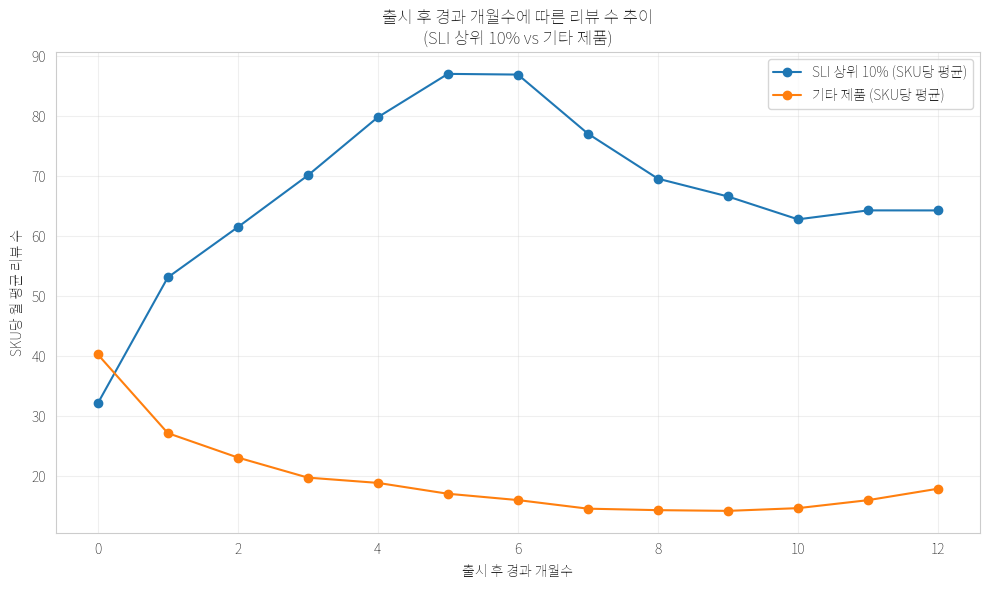

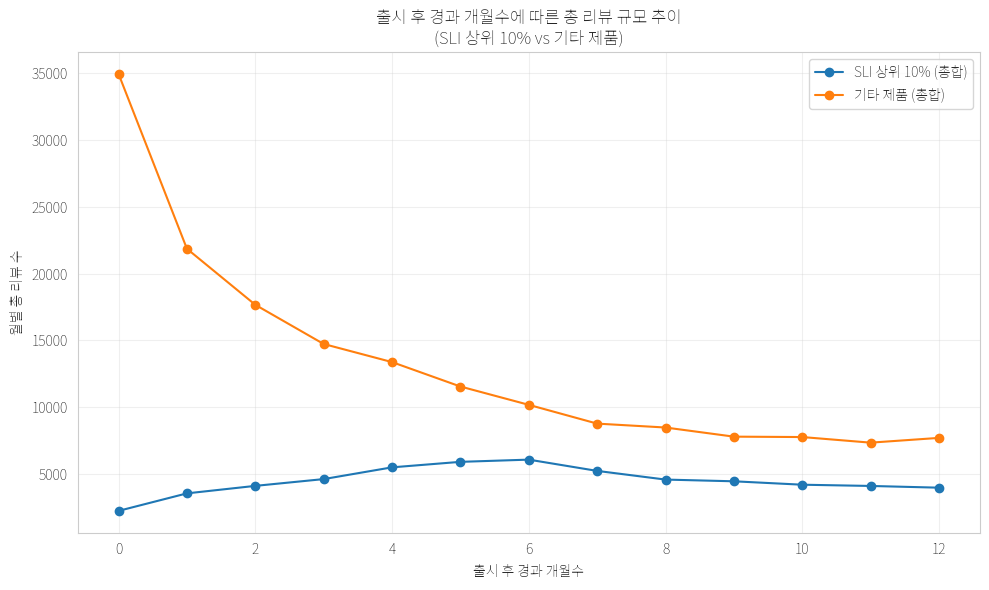

In [77]:

# -------------------------
# 1) SLI 상위 10% SKU 집합 만들기
# -------------------------
threshold = df["SLI"].quantile(0.9)
top10_skus = set(df.loc[df["SLI"] >= threshold, "product_code"])

# -------------------------
# 2) 월별 리뷰 데이터에 Top10 여부 라벨링
# -------------------------
m = monthly_counts[["product_code", "months_since_launch", "review_cnt"]].copy()
m["group"] = np.where(m["product_code"].isin(top10_skus), "SLI Top 10%", "Others")

# -------------------------
# 3) months_since_launch별 평균 리뷰수(또는 합계) 집계
#   - 평균: SKU 당 평균 리뷰 추이
#   - 합계: 해당 그룹 전체 리뷰 볼륨 추이
# -------------------------
# (A) SKU-월 단위로 먼저 정리(혹시 중복이 있으면 합산)
m_sku_month = (
    m.groupby(["product_code", "months_since_launch", "group"], as_index=False)["review_cnt"]
     .sum()
)

# (B-1) 평균 추이 (추천: SKU당 평균)
trend_mean = (
    m_sku_month.groupby(["months_since_launch", "group"], as_index=False)["review_cnt"]
              .mean()
              .rename(columns={"review_cnt": "avg_review_cnt"})
)

# (B-2) 합계 추이 (원하면 사용)
trend_sum = (
    m_sku_month.groupby(["months_since_launch", "group"], as_index=False)["review_cnt"]
              .sum()
              .rename(columns={"review_cnt": "total_review_cnt"})
)

# -------------------------
# 4) 꺾은선 그래프 (평균 추이)
# -------------------------
pivot_mean = trend_mean.pivot(
    index="months_since_launch",
    columns="group",
    values="avg_review_cnt"
).sort_index()

plt.figure(figsize=(10, 6))
plt.plot(pivot_mean.index, pivot_mean["SLI Top 10%"],
         marker="o", label="SLI 상위 10% (SKU당 평균)")
plt.plot(pivot_mean.index, pivot_mean["Others"],
         marker="o", label="기타 제품 (SKU당 평균)")

plt.xlabel("출시 후 경과 개월수")
plt.ylabel("SKU당 월 평균 리뷰 수")
plt.title("출시 후 경과 개월수에 따른 리뷰 수 추이\n(SLI 상위 10% vs 기타 제품)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 5) 합계 추이 그래프
# -------------------------
pivot_sum = trend_sum.pivot(
    index="months_since_launch",
    columns="group",
    values="total_review_cnt"
).sort_index()

plt.figure(figsize=(10, 6))
plt.plot(pivot_sum.index, pivot_sum["SLI Top 10%"],
         marker="o", label="SLI 상위 10% (총합)")
plt.plot(pivot_sum.index, pivot_sum["Others"],
         marker="o", label="기타 제품 (총합)")

plt.xlabel("출시 후 경과 개월수")
plt.ylabel("월별 총 리뷰 수")
plt.title("출시 후 경과 개월수에 따른 총 리뷰 규모 추이\n(SLI 상위 10% vs 기타 제품)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## V1과 V2 두 점수 비교

In [52]:
# ================================
# V2 계산
# ================================

# 1) retention 4phase
retention_4p = compute_retention_4phase(monthly_valid)

# 2) slope 방향성
slope_dir_df = compute_slope_directional(slope_df)

# 3) 후기 변동성
late_vol_df = compute_late_volatility(monthly_valid)

# 4) v2 점수 계산
sli_v2_df = compute_sli_v2(
    retention_4p,
    slope_dir_df,
    late_vol_df,
    volume_df
)

# v1 점수와 merge
compare_df = (
    sli_df[['product_code','sli']]
    .merge(sli_v2_df[['product_code','SLI_v2']], on='product_code')
)

In [73]:
# ================================
# 상위 10% 겹침 비교
# ================================

top_q = 0.10

v1_thr = compare_df['sli'].quantile(1-top_q)
v2_thr = compare_df['SLI_v2'].quantile(1-top_q)

compare_df['v1_top10'] = compare_df['sli'] >= v1_thr
compare_df['v2_top10'] = compare_df['SLI_v2'] >= v2_thr

overlap = (
    (compare_df['v1_top10'] & compare_df['v2_top10']).sum() /
    compare_df['v1_top10'].sum()
)

print("V1 상위10% SKU 수:", compare_df['v1_top10'].sum())
print("V2 상위10% SKU 수:", compare_df['v2_top10'].sum())
print("겹치는 비율:", round(overlap,3))

V1 상위10% SKU 수: 60
V2 상위10% SKU 수: 60
겹치는 비율: 0.65


In [74]:
# ================================
# 브랜드 내부 R스퀘어 비교 (수정본)
# ================================

# v1 점수 포함한 df 생성
df_eval = (
    sli_df[['product_code','sli']]   # v1 점수
    .merge(sli_v2_df[['product_code','SLI_v2']], on='product_code')
    .merge(df_products[['product_code','brand_name','price']], on='product_code')
    .merge(volume_df[['product_code','total_reviews']], on='product_code')
)

# 가상매출 계산
df_eval["sales"] = df_eval["total_reviews"] * df_eval["price"]
df_eval = df_eval[df_eval["sales"] > 0]
df_eval["log_sales"] = np.log(df_eval["sales"])

brand_results = []

for b, g in df_eval.groupby("brand_name"):
    if len(g) < 8:
        continue
    
    m1 = smf.ols("log_sales ~ sli", data=g).fit()
    m2 = smf.ols("log_sales ~ SLI_v2", data=g).fit()
    
    brand_results.append({
        "brand": b,
        "n": len(g),
        "R2_v1": round(m1.rsquared,3),
        "R2_v2": round(m2.rsquared,3)
    })

brand_compare = pd.DataFrame(brand_results).sort_values("R2_v2", ascending=False)

display(brand_compare.tail(10))

,brand,n,R2_v1,R2_v2
18,식물원,10,0.001,0.040
4,닥터오라클,10,0.007,0.035
1,과일나라,10,0.188,0.020
29,플레이101 by 에뛰드,23,0.007,0.018
20,오릭스,9,0.015,0.018
7,더페이스샵,11,0.005,0.010
25,태그,21,0.087,0.009
10,마데카21,9,0.008,0.009
26,투에딧,25,0.080,0.006
0,VT,13,0.060,0.004


## (부록) SLV V1

In [72]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
import statsmodels.api as sm


# =================================================
# 0. 공통 유틸
# =================================================

def _ensure_complete_month_grid_per_sku(monthly_counts: pd.DataFrame, max_month: int = 12) -> pd.DataFrame:
    """
    SKU별 months_since_launch 0..max_month 그리드로 보완(없는 달은 0으로 채움)
    - 기존 방식 유지하되, 변동성 계산을 잔차 기반으로 바꾸면서도
      잔차 계산 안정성을 위해 그리드는 유지
    """
    sku = monthly_counts['product_code'].unique()
    months = np.arange(0, max_month + 1)

    grid = (
        pd.MultiIndex.from_product([sku, months], names=['product_code', 'months_since_launch'])
        .to_frame(index=False)
    )

    out = grid.merge(
        monthly_counts[['product_code', 'months_since_launch', 'review_cnt']],
        on=['product_code', 'months_since_launch'],
        how='left'
    )

    out['review_cnt'] = out['review_cnt'].fillna(0)
    return out


# =================================================
# 1. 최소 리뷰 볼륨 필터 (총 리뷰 최소 30개 이상인 것만)
# =================================================

def filter_by_volume(monthly_counts: pd.DataFrame, min_total_reviews: int = 30) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    returns:
      - monthly_valid: 필터 적용된 monthly_counts
      - volume_df: product_code별 total_reviews
    """
    volume_df = (
        monthly_counts
        .groupby('product_code', as_index=False)['review_cnt']
        .sum()
        .rename(columns={'review_cnt': 'total_reviews'})
    )
    valid_products = volume_df.loc[volume_df['total_reviews'] >= min_total_reviews, 'product_code']
    monthly_valid = monthly_counts[monthly_counts['product_code'].isin(valid_products)].copy()
    return monthly_valid, volume_df


# =================================================
# 2. 3구간 retention (early/mid/late) + 로그 차이
# =================================================

def compute_retention_3phase(
    monthly_valid: pd.DataFrame,
    early_months=(0, 2),
    mid_months=(3, 5),
    late_months=(6, 12),
    agg='median'
) -> pd.DataFrame:
    """
    구간별 집계(중앙값 기본) 후 log1p 차이 계산
    - mid - early : 전이 안정성
    - late - mid  : 지속 유지력
    - late - early: 총 유지력
    """
    lo_e, hi_e = early_months
    lo_m, hi_m = mid_months
    lo_l, hi_l = late_months

    def _agg(s: pd.Series) -> float:
        if agg == 'median':
            return float(s.median())
        elif agg == 'mean':
            return float(s.mean())
        else:
            raise ValueError("agg must be 'median' or 'mean'")

    def _phase(df, lo, hi, colname):
        tmp = (
            df[(df['months_since_launch'] >= lo) & (df['months_since_launch'] <= hi)]
            .groupby('product_code')['review_cnt']
            .apply(_agg)
            .reset_index(name=colname)
        )
        return tmp

    early = _phase(monthly_valid, lo_e, hi_e, 'early_val')
    mid   = _phase(monthly_valid, lo_m, hi_m, 'mid_val')
    late  = _phase(monthly_valid, lo_l, hi_l, 'late_val')

    ret = early.merge(mid, on='product_code', how='inner').merge(late, on='product_code', how='inner')

    ret['log_mid_minus_early']  = np.log1p(ret['mid_val'])  - np.log1p(ret['early_val'])
    ret['log_late_minus_mid']   = np.log1p(ret['late_val']) - np.log1p(ret['mid_val'])
    ret['log_late_minus_early'] = np.log1p(ret['late_val']) - np.log1p(ret['early_val'])

    return ret


# =================================================
# 3. slope: SKU별 OLS + p-value
# =================================================

def compute_slope_ols(
    monthly_valid: pd.DataFrame,
    min_points: int = 6,
    alpha: float = 0.05,
    nonsig_policy: str = "zero"  # "zero" 또는 "shrink"
) -> pd.DataFrame:
    """
    SKU별 OLS: y=review_cnt, x=months_since_launch
    - slope, pvalue 산출
    - 유의하지 않으면 slope=0(기본) 또는 shrink(패널티 완화)
    """
    rows = []
    for pid, g in monthly_valid.groupby('product_code'):
        g2 = g[['months_since_launch', 'review_cnt']].dropna()
        if len(g2) < min_points:
            continue

        X = sm.add_constant(g2['months_since_launch'].astype(float))
        y = g2['review_cnt'].astype(float)

        try:
            model = sm.OLS(y, X).fit()
            slope = float(model.params['months_since_launch'])
            pval = float(model.pvalues['months_since_launch'])
        except Exception:
            continue

        slope_eff = slope
        if pval >= alpha:
            if nonsig_policy == "zero":
                slope_eff = 0.0
            elif nonsig_policy == "shrink":
                w = max(0.0, min(1.0, (1.0 - pval) / (1.0 - alpha)))
                slope_eff = slope * w
            else:
                raise ValueError("nonsig_policy must be 'zero' or 'shrink'")

        rows.append({
            'product_code': pid,
            'slope_raw': slope,
            'slope_pvalue': pval,
            'slope_eff': slope_eff
        })

    return pd.DataFrame(rows)


# =================================================
# 4. 변동성(개선): 추세 제거 잔차 변동성(residual volatility)
#    - 대형 SKU의 "자연스러운 규모 변동"을 과벌점 주지 않기 위함
#    - rolling_std / CV 대신, OLS 잔차 기반 지표로 패널티
# =================================================

def compute_volatility_residual(
    monthly_valid: pd.DataFrame,
    max_month: int = 12,
    min_points: int = 6,
    eps: float = 1e-9
) -> pd.DataFrame:
    """
    returns:
      - resid_std: 추세 제거 후 잔차 표준편차 (비정상적 튐)
      - resid_cv : resid_std / (mean + eps)  (규모 보정된 잔차 변동성)
    """
    filled = _ensure_complete_month_grid_per_sku(monthly_valid, max_month=max_month)
    filled = filled.sort_values(['product_code', 'months_since_launch'])

    rows = []
    for pid, g in filled.groupby('product_code'):
        g2 = g[['months_since_launch', 'review_cnt']].dropna()

        if len(g2) < min_points:
            continue

        X = sm.add_constant(g2['months_since_launch'].astype(float))
        y = g2['review_cnt'].astype(float)

        try:
            model = sm.OLS(y, X).fit()
            resid = model.resid
        except Exception:
            continue

        resid_std = float(np.std(resid, ddof=0))
        mean_level = float(np.mean(y))

        rows.append({
            'product_code': pid,
            'resid_std': resid_std,
            'resid_cv': resid_std / (mean_level + eps)
        })

    return pd.DataFrame(rows)


# =================================================
# 5. 표준화 + sli 산출 (매출 기여형 안정 SKU 목적)
#    - 규모(total_reviews)를 (+)로 반영
#    - 변동성은 residual 기반으로 약하게 패널티
#    - (선택) price를 받아 log_revenue_proxy도 (+) 반영 가능
# =================================================

def compute_sli(
    retention_3p: pd.DataFrame,
    slope_df: pd.DataFrame,
    vol_df: pd.DataFrame,
    volume_df: pd.DataFrame,
    df_products: pd.DataFrame | None = None,   # price 반영 옵션
    use_revenue_proxy: bool = False,           # True면 log(total_reviews*price) 사용
    scaler_type: str = "robust",
    weights: dict | None = None,
) -> pd.DataFrame:
    """
    표준화(필수) 후 가중합 sli 생성
    - 유지율: (mid-early), (late-mid), (late-early)
    - slope_eff: 표준화 후 abs 패널티
    - volatility: resid_cv (또는 resid_std) 표준화 후 약한 패널티
    - size: log_total_reviews (매출 기여/규모) 표준화 후 + 가중치
    - (옵션) revenue_proxy: log(total_reviews*price)
    """
    if weights is None:
        # "효자상품(매출 기여 + 안정)" 목적 기본값
        # - 유지력(0.70)
        # - 규모(0.20)
        # - 추세/변동 리스크(0.10)
        weights = {
            'log_mid_minus_early':   0.20,
            'log_late_minus_mid':    0.30,
            'log_late_minus_early':  0.20,
            'size':                  0.20,   # 핵심: 규모를 올려줌
            'slope_eff_abs':         0.06,
            'vol_resid':             0.04
        }

    df = retention_3p.merge(slope_df, on='product_code', how='inner')
    df = df.merge(vol_df, on='product_code', how='inner')
    df = df.merge(volume_df, on='product_code', how='inner')

    # 규모(리뷰 볼륨) 피처
    df['log_total_reviews'] = np.log1p(df['total_reviews'])

    # (옵션) 가상매출 proxy까지 점수에 반영하고 싶으면
    if use_revenue_proxy:
        if df_products is None:
            raise ValueError("use_revenue_proxy=True이면 df_products(가격 포함)가 필요합니다.")
        df = df.merge(df_products[['product_code', 'price']], on='product_code', how='left')
        df = df.dropna(subset=['price'])
        df['revenue_proxy'] = df['total_reviews'] * df['price']
        df['log_revenue_proxy'] = np.log1p(df['revenue_proxy'])

    # ----- 표준화 대상 -----
    base_cols = [
        'log_mid_minus_early',
        'log_late_minus_mid',
        'log_late_minus_early',
        'slope_eff',
        'resid_cv',
        'log_total_reviews'
    ]
    if use_revenue_proxy:
        # 규모 대신 매출 proxy를 쓰고 싶다면(선택): 아래 줄을 켜고 size 가중치 해석 변경
        base_cols.append('log_revenue_proxy')

    X = df[base_cols].copy()

    if scaler_type == "standard":
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
    elif scaler_type == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError("scaler_type must be 'standard' or 'robust'")

    Z = scaler.fit_transform(X)
    Z = pd.DataFrame(Z, columns=[c + "_z" for c in base_cols], index=df.index)
    df = pd.concat([df, Z], axis=1)

    # 패널티는 표준화 후 적용
    df['slope_eff_abs_z'] = df['slope_eff_z'].abs()

    # 변동성: 잔차 기반 (규모 큰 SKU 과벌점 완화)
    df['vol_resid_z'] = df['resid_cv_z']  # 필요시 resid_std로 바꿔도 됨

    # size: 기본은 log_total_reviews_z
    df['size_z'] = df['log_total_reviews_z']

    # (옵션) 매출 proxy를 size로 쓰고 싶으면
    if use_revenue_proxy:
        df['size_z'] = df['log_revenue_proxy_z']

    # ----- sli (효자상품형) -----
    df['sli'] = (
        weights['log_mid_minus_early']  * df['log_mid_minus_early_z'] +
        weights['log_late_minus_mid']   * df['log_late_minus_mid_z'] +
        weights['log_late_minus_early'] * df['log_late_minus_early_z'] +
        weights['size']                * df['size_z'] -
        weights['slope_eff_abs']       * df['slope_eff_abs_z'] -
        weights['vol_resid']           * df['vol_resid_z']
    )

    df['sli_zscore'] = (df['sli'] - df['sli'].mean()) / (df['sli'].std(ddof=0) + 1e-9)

    return df


# =================================================
# 6. 절대/상대 기준 병행 + 요약 리포트
# =================================================

def classify_and_report(
    sli_df: pd.DataFrame,
    df_products: pd.DataFrame,
    top_q_list=(0.20, 0.10)
) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    """
    returns:
      - thresholds dict
      - report_df (요약)
      - final_df (상품정보 포함 전체 sli 결과)
    """
    final_df = sli_df.merge(
        df_products[['product_code','name','category_1','category_2', 'price']],
        on='product_code',
        how='left'
    )

    final_df['is_soft_abs'] = (final_df['sli'] > 0).astype(int)

    thresholds = {}
    for q in top_q_list:
        thr = final_df['sli'].quantile(1 - q)
        thresholds[f"top_{int(q*100)}"] = thr
        final_df[f'is_soft_top_{int(q*100)}'] = (final_df['sli'] >= thr).astype(int)

    n_valid = final_df['product_code'].nunique()
    sli_mean = final_df['sli'].mean()
    sli_std = final_df['sli'].std(ddof=0)

    rows = [{
        "전체 유효 SKU 수": n_valid,
        "sli 평균": round(sli_mean, 4),
        "sli 표준편차": round(sli_std, 4),
        "연착륙 비율(절대: sli>0)": round(final_df['is_soft_abs'].mean(), 4),
    }]

    for q in top_q_list:
        col = f'is_soft_top_{int(q*100)}'
        rows[0][f"연착륙 비율(상대: 상위 {int(q*100)}%)"] = round(final_df[col].mean(), 4)

    report_df = pd.DataFrame(rows)

    out_cols = [
        'product_code','name','category_1','category_2','price',
        'total_reviews','sli','sli_zscore',
        'is_soft_abs'
    ] + [f'is_soft_top_{int(q*100)}' for q in top_q_list]

    final_df_out = final_df[out_cols].sort_values('sli', ascending=False)

    return thresholds, report_df, final_df_out


# =================================================
# 7. 실행 파이프라인
# =================================================

# 1) 볼륨 필터
monthly_valid, volume_df = filter_by_volume(monthly_counts, min_total_reviews=30)

# 2) 3구간 retention
retention_3p = compute_retention_3phase(
    monthly_valid,
    early_months=(0, 2),
    mid_months=(3, 5),
    late_months=(6, 12),
    agg='median'
)

# 3) OLS slope + pvalue (유의하지 않으면 0)
slope_df = compute_slope_ols(
    monthly_valid,
    min_points=6,
    alpha=0.05,
    nonsig_policy="zero"
)

# 4) 변동성(잔차 기반)
vol_df = compute_volatility_residual(
    monthly_valid,
    max_month=12,
    min_points=6
)

# 5) 표준화 + sli (효자상품형)
# - use_revenue_proxy=False: 규모는 total_reviews만 반영
# - use_revenue_proxy=True : 규모 대신 (total_reviews*price) 반영(더 “매출형”)
sli_df = compute_sli(
    retention_3p=retention_3p,
    slope_df=slope_df,
    vol_df=vol_df,
    volume_df=volume_df,
    df_products=df_products,     # use_revenue_proxy=True면 필수
    use_revenue_proxy=False,     # 필요 시 True로 바꿔
    scaler_type="robust",
    weights=None 
)

# 6) 절대/상대 기준 + 요약 리포트 + 최종 출력
thresholds, report_df, soft_landing_results = classify_and_report(
    sli_df,
    df_products=df_products,
    top_q_list=(0.20, 0.10)
)

print("=== sli 임계값 ===")
for k, v in thresholds.items():
    print(f"{k}: {v:.4f}")

print("\n=== 요약 리포트(한국어) ===")
display(report_df)

print("\n=== 연착륙 후보 결과(상품정보 포함) 상위 30개 ===")
display(soft_landing_results.head(30))

# 중간 산출물:
# monthly_valid, volume_df, retention_3p, slope_df, vol_df, sli_df, report_df, soft_landing_results

=== sli 임계값 ===
top_20: 0.4015
top_10: 0.5797

=== 요약 리포트(한국어) ===


,전체 유효 SKU 수,sli 평균,sli 표준편차,연착륙 비율(절대: sli>0),연착륙 비율(상대: 상위 20%),연착륙 비율(상대: 상위 10%)
0,691,-0.0285,0.4955,0.5051,0.2012,0.1013



=== 연착륙 후보 결과(상품정보 포함) 상위 30개 ===


,product_code,name,category_1,category_2,price,total_reviews,sli,sli_zscore,is_soft_abs,is_soft_top_20,is_soft_top_10
230,1051749,닥터오라클 큐어소나 래디언스 글로우 앰플 40 ml,스킨케어,기초스킨케어,5000.0,720,1.470078,3.024326,1,1,1
71,1038595,제이엠솔루션 B5 히아 모이스처라이징 부스트 토너 XL 500 ml,스킨케어,기초스킨케어,5000.0,129,1.433612,2.950733,1,1,1
356,1060216,센카 퍼펙트 휩 클렌징 폼 50 g 베리브라이트,스킨케어,클렌징/필링,3000.0,93,1.281559,2.643868,1,1,1
357,1060217,센카 퍼펙트 휩 클렌징 폼 50 g 화이트,스킨케어,클렌징/필링,3000.0,124,1.151641,2.381675,1,1,1
355,1060215,센카 퍼펙트 휩 클렌징 폼 50 g 프레시,스킨케어,클렌징/필링,3000.0,254,1.138342,2.354836,1,1,1
204,1049277,VT 시카 슬리핑 마스크 4 ml 6개입,스킨케어,팩/마스크,3000.0,2250,1.086784,2.250783,1,1,1
207,1050177,바세린 립 테라피 4.8 g 오리지널 2개입,스킨케어,립케어,5000.0,146,1.031977,2.140176,1,1,1
134,1044970,어퓨 더퓨어 티트리 스팟 세럼 8ml,스킨케어,기초스킨케어,3000.0,1434,1.007057,2.089884,1,1,1
232,1051751,닥터오라클 큐어소나 리커버링 릴렉싱 크림 60 ml,스킨케어,기초스킨케어,5000.0,369,1.004728,2.085183,1,1,1
684,1067495,VT PDRN 광채토너 200 ml,스킨케어,기초스킨케어,5000.0,524,0.969185,2.013453,1,1,1
